In [169]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [170]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sys.path.append('../src')

from data_pipeline import load_all_raw_data
from data_analysis import (
    filter_data_until_date, temporal_split_data, 
    plot_user_analysis, plot_temporal_analysis, 
    plot_station_analysis, plot_activity_heatmap, 
    print_summary_statistics
)
from preprocess import (
    analyze_users_for_visualization, 
    analyze_trips_for_visualization
)


In [171]:

raw_data_dir = Path('../data/raw')
save_dir = Path('../data/raw/combined')

users_df, trips_df = load_all_raw_data(raw_data_dir, save_dir, verbose=True)

print(f"Datos cargados: {len(users_df):,} usuarios, {len(trips_df):,} viajes")


INICIANDO CARGA OPTIMIZADA DE DATOS RAW
Cargando datos de usuarios...
Cargando: usuarios_ecobici_2020.csv
   107,166 filas cargadas en 0.13s
Cargando: usuarios_ecobici_2021.csv
   81,577 filas cargadas en 0.07s
Cargando: usuarios_ecobici_2022.csv
   105,997 filas cargadas en 29.14s
Cargando: usuarios_ecobici_2023.csv
   136,066 filas cargadas en 0.15s
Cargando: usuarios_ecobici_2024.csv


KeyboardInterrupt: 

In [ ]:
print("🔍 ORIGINAL RAW DATA ANALYSIS (BEFORE PREPROCESSING)")
print("=" * 60)

print("Number of null values per column (ORIGINAL):")
nan_counts_original = trips_df.isnull().sum()
print(nan_counts_original)

print("\nPercentage of null values per column (ORIGINAL):")
nan_percentages_original = (trips_df.isnull().sum() / len(trips_df) * 100).round(2)
print(nan_percentages_original)

print("\nMin and max values per column:")
for col in trips_df.columns:
    try:
        min_val = trips_df[col].min()
        max_val = trips_df[col].max()
        print(f"\n{col}:")
        print(f"  Min: {min_val}")
        print(f"  Max: {max_val}")
    except:
        print(f"\n{col}: Cannot calculate min/max (likely non-numeric)")

print(f"\nOriginal dataset shape: {trips_df.shape}")
print(f"Original columns: {list(trips_df.columns)}")

key_cols = ['id_recorrido', 'id_estacion_origen', 'id_estacion_destino', 'id_usuario', 'duracion_recorrido', 'genero']


🔍 ORIGINAL RAW DATA NaN ANALYSIS (BEFORE PREPROCESSING)
Number of null values per column (ORIGINAL):
id_recorrido                      0
duracion_recorrido              270
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido        3379
id_estacion_destino              43
nombre_estacion_destino          43
direccion_estacion_destino       43
long_estacion_destino            43
lat_estacion_destino             43
id_usuario                        0
modelo_bicicleta                  0
genero                        76061
dtype: int64

Percentage of null values per column (ORIGINAL):
id_recorrido                  0.00
duracion_recorrido            0.00
fecha_origen_recorrido        0.00
id_estacion_origen            0.00
nombre_estacion_origen        0.00
direccion_estacion_origen     0.00
long_estacion_

In [156]:

users_filtered, trips_filtered = filter_data_until_date(
    users_df, trips_df, 
    max_date="2024-08-31",
    verbose=False
)


In [157]:

data_splits = temporal_split_data(
    users_filtered, trips_filtered,
    train_end_date="2023-06-30",  # Train until jun 2023
    val_end_date="2023-12-31",    # Val jul-dec 2023  
    test_end_date="2024-08-31",   # Test jan-aug 2024
    verbose=False
)


In [ ]:

users_train = data_splits['users_train']
users_val = data_splits['users_val'] 
users_test = data_splits['users_test']

trips_train = data_splits['trips_train']
trips_val = data_splits['trips_val']
trips_test = data_splits['trips_test']


print(f"Users: Train={len(users_train):,}, Val={len(users_val):,}, Test={len(users_test):,}")
print(f"Trips: Train={len(trips_train):,}, Val={len(trips_val):,}, Test={len(trips_test):,}")
print(f"Final columns: {list(trips_train.columns)}")


Users: Train=346,517, Val=84,289, Test=115,204
Trips: Train=9,505,149, Val=1,312,801, Test=2,158,103
Final columns: ['id_recorrido', 'duracion_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'long_estacion_origen', 'lat_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'long_estacion_destino', 'lat_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'genero']



Estadísticas de entrenamiento:
Usuarios en train: (346517, 5)
Viajes en train: (9505149, 17)

Generando análisis de usuarios...


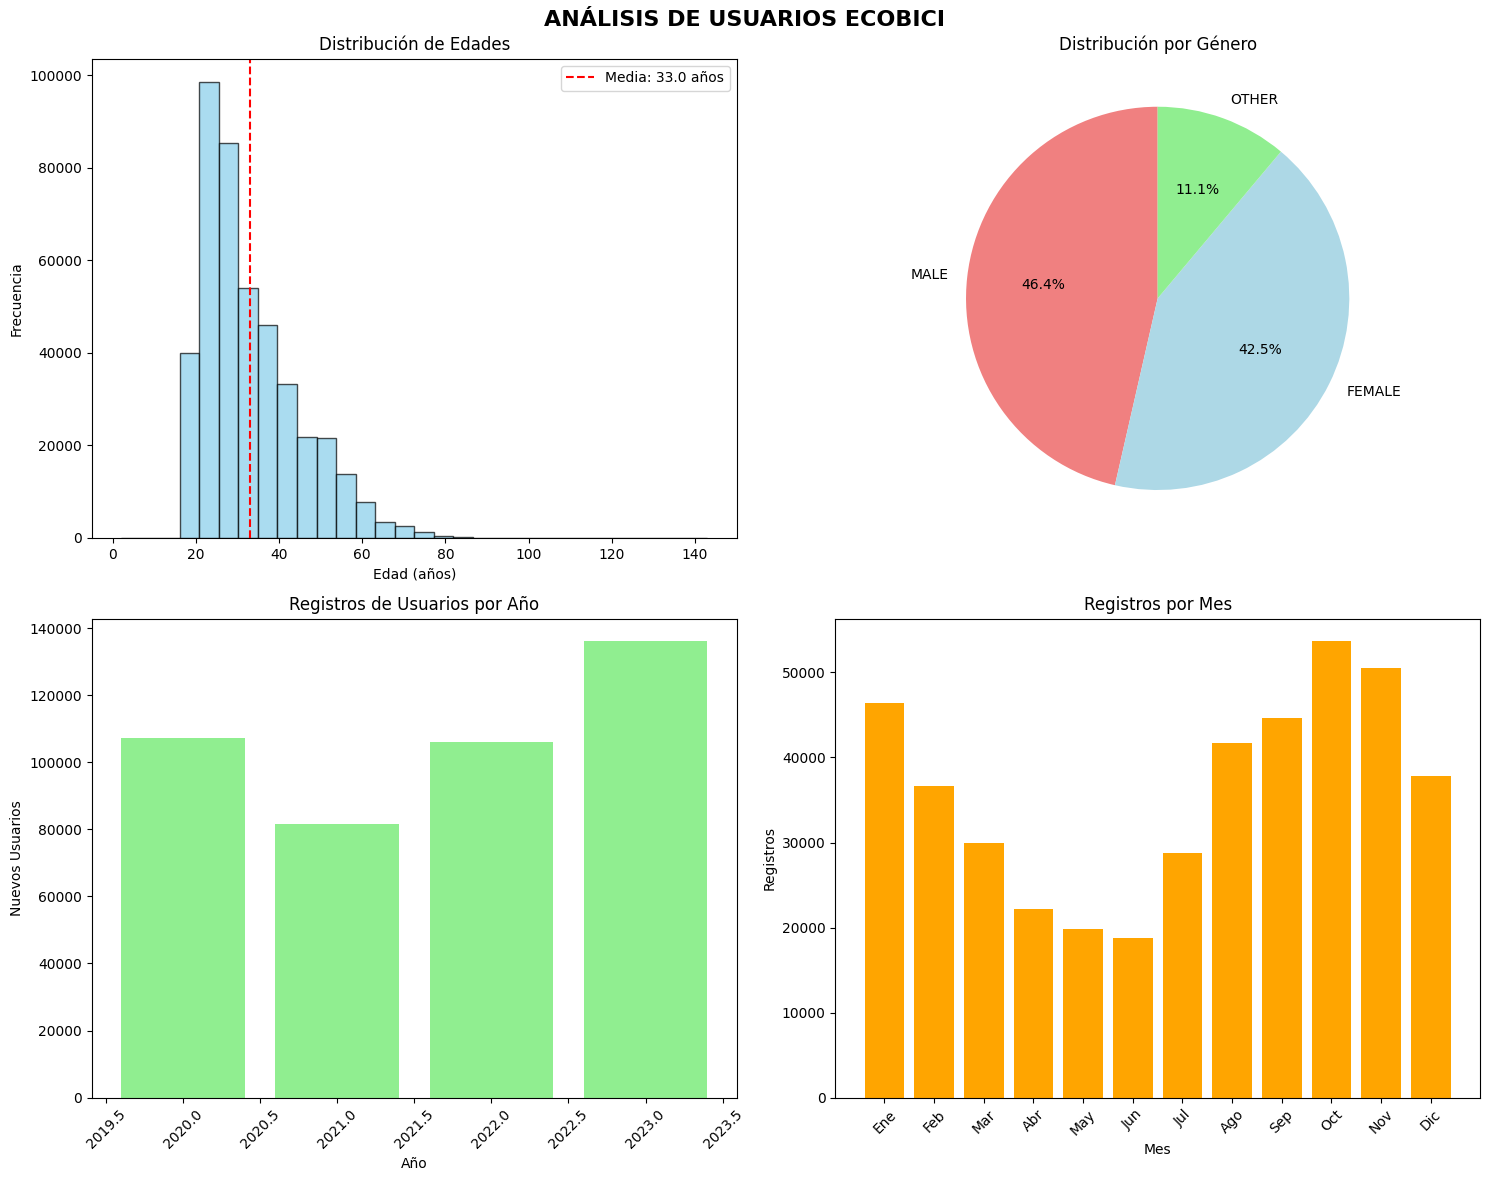

Generando análisis temporal...


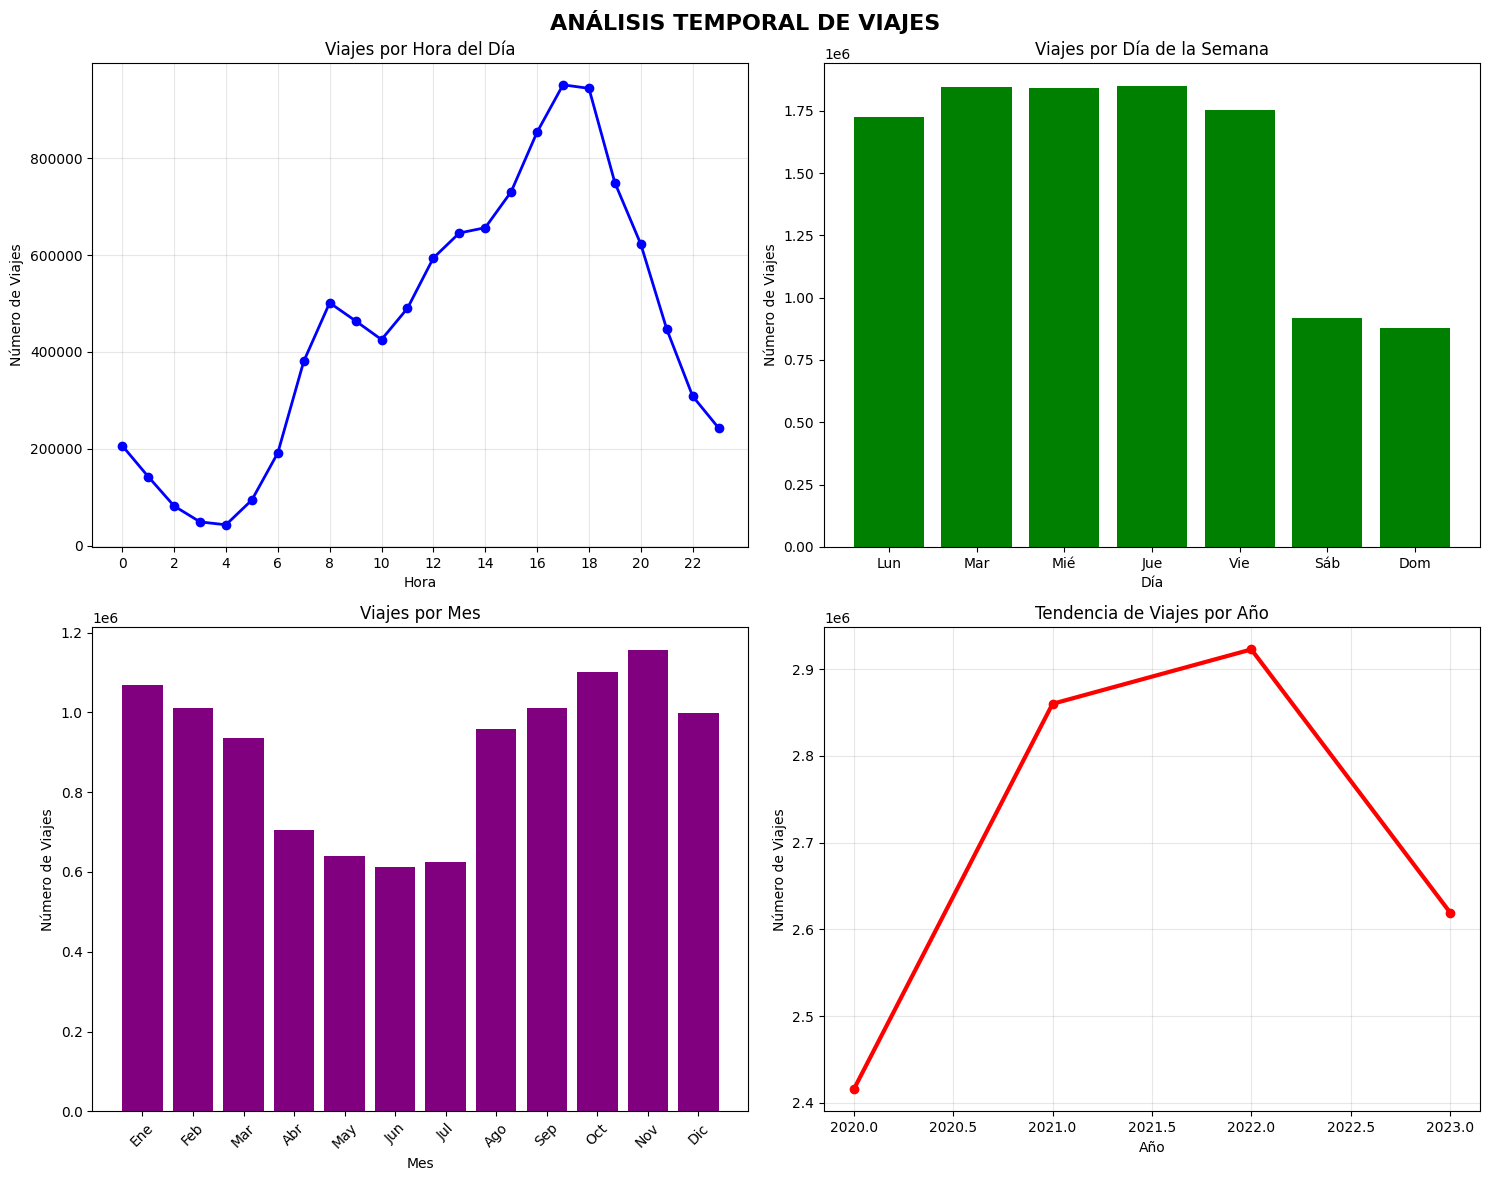

Generando análisis de estaciones...
2.00145 16.65


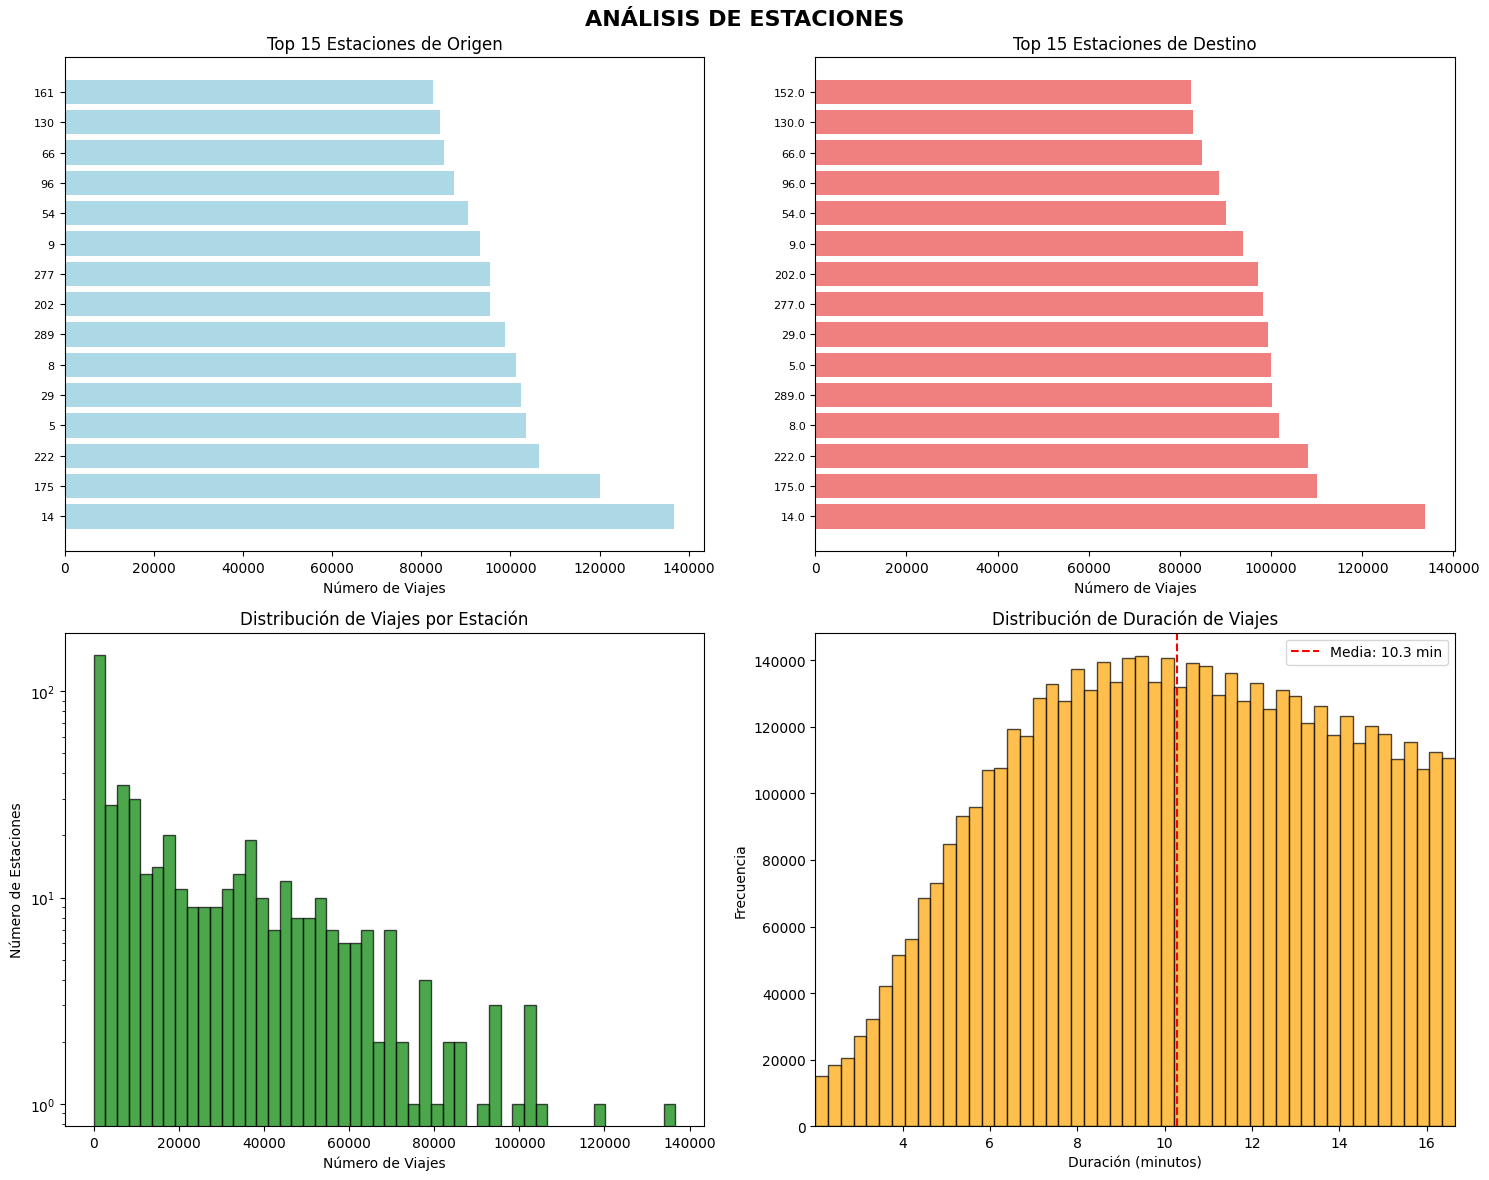

Generando heatmap de actividad...


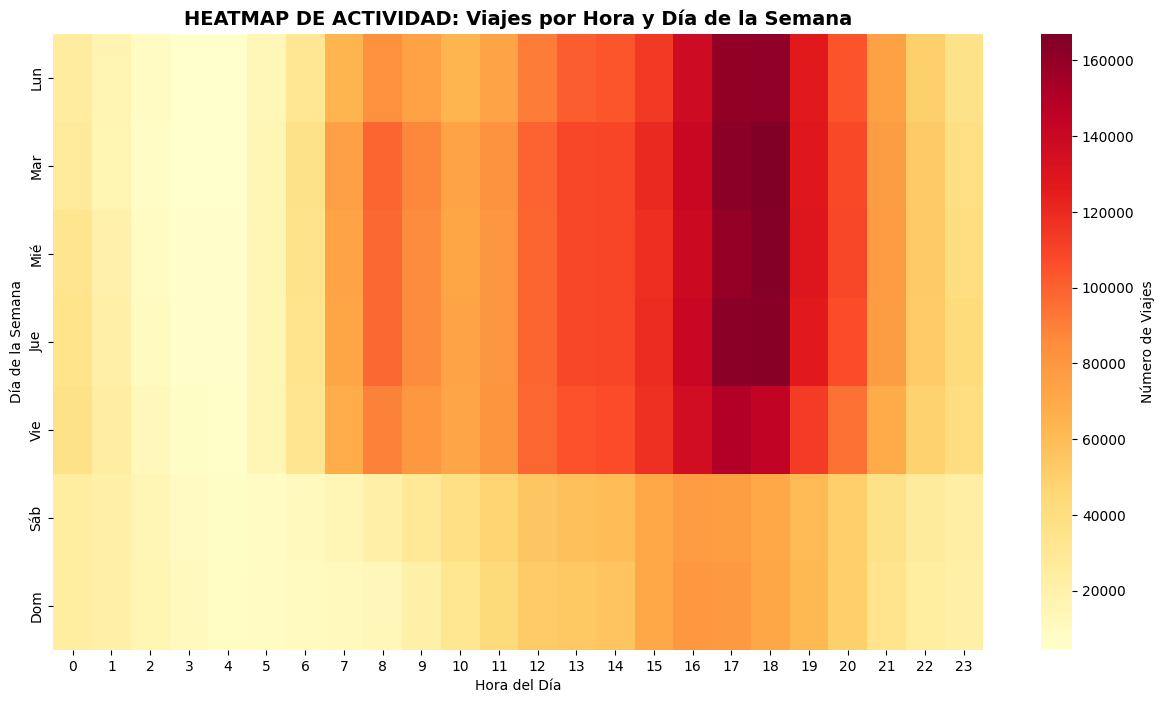


ESTADÍSTICAS RESUMEN
USUARIOS:
   • Total usuarios: 546,010
   • Edad promedio: 33.0 años
   • Distribución de género:
     - MALE: 199,987 (36.6%)
     - FEMALE: 182,907 (33.5%)
     - OTHER: 47,910 (8.8%)

VIAJES:
   • Total viajes: 12,976,053
   • Período: 2020-01-01 00:00:08 - 2023-12-30 23:59:32
   • Promedio viajes/día: 8,888
   • Estaciones únicas (origen): 484
   • Estaciones únicas (destino): 15
   • Duración promedio: 10.3 minutos


In [159]:
# combine train and validation data first, then analyze
users_combined = pd.concat([users_train, users_val], axis=0)
trips_combined = pd.concat([trips_train, trips_val], axis=0)

# analyze combined data
processed_users = analyze_users_for_visualization(users_combined)
processed_trips = analyze_trips_for_visualization(trips_combined)

# print training statistics
print(f"\nEstadísticas de entrenamiento:")
print(f"Usuarios en train: {users_train.shape}")
print(f"Viajes en train: {trips_train.shape}")

# generate analysis plots
print("\nGenerando análisis de usuarios...")
plot_user_analysis(processed_users, save_plots=False, output_dir=None)

print("Generando análisis temporal...")
plot_temporal_analysis(processed_trips, save_plots=False, output_dir=None)

print("Generando análisis de estaciones...")
plot_station_analysis(processed_trips, save_plots=False, output_dir=None)

print("Generando heatmap de actividad...")
plot_activity_heatmap(processed_trips, save_plots=False, output_dir=None)

# print summary statistics
print_summary_statistics(users_filtered, processed_users, trips_filtered, processed_trips)


In [133]:
trips_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,7210548,1.582,2020-01-24 21:54:39,27,027 - Montevideo,Cordoba Av. & Montevideo,-58.390087,-34.599068,2020-01-24 22:21:01,3.0,003 - ADUANA,Moreno & Av Paseo Colon,-58.368259,-34.611031,192009.0,ICONIC,FEMALE
1,7199093,204.000,2020-01-24 07:04:19,151,151 - AIME PAINÉ,"Villaflor, Azucena & Paine, Aime",-58.361286,-34.611816,2020-01-24 07:07:43,3.0,003 - ADUANA,Moreno & Av Paseo Colon,-58.368259,-34.611031,36380.0,ICONIC,MALE
2,7196805,1.790,2020-01-24 00:15:17,111,111 - MACACHA GUEMES,Machaca Guemes 350,-58.364685,-34.605488,2020-01-24 00:45:07,3.0,003 - ADUANA,Moreno & Av Paseo Colon,-58.368259,-34.611031,460080.0,ICONIC,MALE
3,7203598,10.688,2020-01-24 12:38:16,285,400 - Reserva Ecologica,"Achaval Rodriguez, T., Dr. Av. 1520",-58.356174,-34.617210,2020-01-24 15:36:24,4.0,004 - Plaza Roma,Lavalle & Bouchard,-58.368782,-34.601822,3857.0,ICONIC,MALE
4,7200335,673.000,2020-01-24 08:31:01,171,171 - Pasteur,519 Pasteur,-58.399754,-34.603283,2020-01-24 08:42:14,7.0,007 - OBELISCO,CARLOS PELEGRINI 215,-58.381100,-34.606499,391034.0,ICONIC,FEMALE
